### Introduction

This case study applies a comprehensive Knowledge Uplift Trail to analyze the patient treatment process within a Brazilian emergency department.

In [ ]:
!pip install pm4py
import pandas as pd
import pm4py
from pm4py.objects.log.util import dataframe_utils
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery
from pm4py.algo.discovery.heuristics import algorithm as heuristics_miner

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

#### 1. Data Loading and Understanding

This section focuses on the initial ingestion and structural overview of the event log. Each row within this log represents a distinct event, crucial for subsequent process mining analyses. This step is fundamental to enable subsequent process mining analysis.

In [ ]:
# --- Data Loading ---
# The event log is imported as a structured dataset where each row represents an event.
# This step is fundamental to enable subsequent process mining analysis.
df = pd.read_csv('UpFLux_Healthcare_Database_labeled.csv')

# The dataset follows the event log paradigm, where specific columns represent core process mining attributes:
# - 'case:concept:name': Identifies the process instance (e.g., a patient's journey).
# - 'concept:name': Represents the activity performed within a case.
# - 'time:timestamp': Denotes the execution time of an activity.

# Ensure column names are in the PM4Py standard format if needed
df = dataframe_utils.convert_timestamp_columns_in_df(df)

# Rename columns to PM4Py standard (adjust these if your column names are different)
# Assuming: case ID, activity name, timestamp
# Example: 'case_id', 'activity_name', 'timestamp'
# If your columns are different, modify them here.
# For example, if 'id_caso' is case ID, 'nome_attivita' is activity name, 'data_ora' is timestamp:
# df = df.rename(columns={'id_caso': 'case:concept:name',
#                          'nome_attivita': 'concept:name',
#                          'data_ora': 'time:timestamp'})

# If your 'case:concept:name', 'concept:name', 'time:timestamp' are already correct, no renaming needed.
# For this notebook, I'll assume they are already named as such from the prompt context.

# Display first few rows to confirm successful loading and initial structure.
display(df.head())

# Display basic statistics to understand data distribution and identify potential issues.
display(df.describe(include='all'))

# Display activity frequency to understand the distribution of activities within the log.
display(df['concept:name'].value_counts())

,case:concept:name,Idade,Sexo,Nível de Urgência,CID,Médico Responsável,Doença,Data Inicial,time:timestamp,concept:name,Item,Data Prescrição,Tempo Processo,Setor,Quantidade,Retorno,Multipassante,Convênio,outlier_label
0,5446538,31,F,Não informado,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 10:22:00+00:00,2020-07-21 10:22:00+00:00,Atendimento,Atendimento,NaT,NaN,Setor Pronto Atendimento,0.0,Sem retorno,Não,Convênio 9,outlier
1,5446538,31,F,Não informado,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 10:45:00+00:00,2020-07-21 10:49:00+00:00,Triagem,Triagem,NaT,NaN,Setor Pronto Atendimento,0.0,Sem retorno,NaN,Convênio 9,outlier
2,5446538,31,F,Não informado,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 11:01:00+00:00,2020-07-21 11:01:00+00:00,Exames Laboratoriais,Coronavírus COVID-19 - Diagnóstico Molecular (...,2020-07-21 10:51:00+00:00,9.0,Setor Pronto Atendimento,1.0,Sem retorno,NaN,Convênio 9,outlier
3,5446538,31,F,Não informado,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 11:32:00+00:00,2020-07-21 11:32:00+00:00,Consulta,Consulta,NaT,NaN,Setor Pronto Atendimento,0.0,Sem retorno,NaN,Convênio 9,outlier
4,5446538,31,F,Não informado,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 19:27:00+00:00,2020-07-21 19:27:00+00:00,Alta,Alta para completar tratamento,NaT,NaN,Setor Pronto Atendimento,0.0,Sem retorno,NaN,Convênio 9,outlier


,case:concept:name,Idade,Sexo,Nível de Urgência,CID,Médico Responsável,Doença,Data Inicial,time:timestamp,concept:name,Item,Data Prescrição,Tempo Processo,Setor,Quantidade,Retorno,Multipassante,Convênio,outlier_label
count,3.093000e+03,3093.000000,3093,3093,3093,3093,3093,3091,3075,3093,3093,378,377.000000,3093,2938.000000,3093,443,3093,3093
unique,NaN,NaN,2,9,7,27,7,NaN,NaN,9,149,NaN,NaN,1,NaN,4,2,11,2
top,NaN,NaN,F,Baixo,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,NaN,NaN,Medicamentos,Atendimento,NaN,NaN,Setor Pronto Atendimento,NaN,Sem retorno,Não,Convênio 9,inlier
freq,NaN,NaN,1689,1554,1790,910,1790,NaN,NaN,494,443,NaN,NaN,3093,NaN,2856,429,901,2689
mean,5.453846e+06,42.119625,NaN,NaN,NaN,NaN,NaN,2020-06-26 23:23:56.292461+00:00,2020-07-27 12:47:16.878048+00:00,NaN,NaN,2020-06-21 02:28:48.888889+00:00,40.769231,NaN,1.082369,NaN,NaN,NaN,NaN
min,5.446538e+06,7.000000,NaN,NaN,NaN,NaN,NaN,2020-01-08 03:33:00+00:00,2020-07-21 10:22:00+00:00,NaN,NaN,2020-01-08 04:21:00+00:00,0.000000,NaN,-20.000000,NaN,NaN,NaN,NaN
25%,5.449966e+06,30.000000,NaN,NaN,NaN,NaN,NaN,2020-07-21 16:56:00+00:00,2020-07-23 16:00:00+00:00,NaN,NaN,2020-07-22 10:57:00+00:00,9.000000,NaN,0.000000,NaN,NaN,NaN,NaN
50%,5.453068e+06,40.000000,NaN,NaN,NaN,NaN,NaN,2020-07-23 19:49:00+00:00,2020-07-27 11:27:00+00:00,NaN,NaN,2020-07-24 09:30:00+00:00,23.000000,NaN,0.000000,NaN,NaN,NaN,NaN
75%,5.458022e+06,52.000000,NaN,NaN,NaN,NaN,NaN,2020-07-28 09:44:30+00:00,2020-07-30 18:07:00+00:00,NaN,NaN,2020-07-28 10:10:00+00:00,53.000000,NaN,1.000000,NaN,NaN,NaN,NaN
max,5.463012e+06,90.000000,NaN,NaN,NaN,NaN,NaN,2020-07-31 22:18:00+00:00,2020-08-05 07:42:00+00:00,NaN,NaN,2020-07-31 21:10:00+00:00,640.000000,NaN,200.000000,NaN,NaN,NaN,NaN


concept:name
Medicamentos                 494
Materiais Hospitalares       455
Atendimento                  443
Consulta                     443
Alta                         443
Triagem                      437
Exames Laboratoriais         223
Exames de Imagem             133
Exames Eletrofisiológicos     22
Name: count, dtype: int64

#### 2. Preprocessing — Filtering (Data Cleaning)

**Objective**: To enhance data quality by removing noise and invalid cases.

**--- Data Preprocessing ---**
To ensure data quality, incomplete events (missing timestamps or activities) are removed. Additionally, extreme outliers (e.g., negative `Quantidade`, `Idade` > 120) and rare activities are filtered to reduce noise and improve model reliability. This step is crucial for obtaining an accurate representation of the process behavior by eliminating irrelevant or erroneous data points.

In [ ]:
# Identify and print potential data quality issues
print("Data Quality Check:")
print("Negative Quantidade:", (df['Quantidade'] < 0).sum())
print("Extreme Idade > 120:", (df['Idade'] > 120).sum())
print("Missing urgency:", df['Nível de Urgência'].isna().sum())
print("Duplicated rows:", df.duplicated().sum())

# Remove events without 'concept:name' (activity) or 'time:timestamp'
df_filtered = df.dropna(subset=["concept:name", "time:timestamp"]).copy()

# Filter values for 'Idade' and 'Quantidade'
df_filtered = df_filtered[(df_filtered['Idade'].isna()) | ((df_filtered['Idade'] >= 0) & (df_filtered['Idade'] <= 120))].copy()
df_filtered = df_filtered[(df_filtered['Quantidade'].isna()) | (df_filtered['Quantidade'] >= 0)].copy()

# Filter rare activities (frequency < 10, as per example structure)
# Calculate frequency of each activity
activity_freq = df_filtered['concept:name'].value_counts()

# Get activities that appear more than 10 times
common_activities = activity_freq[activity_freq > 10].index

# Filter the DataFrame to include only common activities
df_filtered = df_filtered[df_filtered['concept:name'].isin(common_activities)].copy()

print(f"\nOriginal number of events: {len(df)}")
print(f"Number of events after filtering: {len(df_filtered)}")
display(df_filtered.head())

# Check case length statistics
case_len = df_filtered.groupby('case:concept:name').size()
print("\nCase Length Statistics:")
display(case_len.describe())
print(f"Cases with 1 event: {(case_len == 1).sum()}")

Data Quality Check:
Negative Quantidade: 17
Extreme Idade > 120: 0
Missing urgency: 0
Duplicated rows: 4

Original number of events: 3093
Number of events after filtering: 3058


,case:concept:name,Idade,Sexo,Nível de Urgência,CID,Médico Responsável,Doença,Data Inicial,time:timestamp,concept:name,Item,Data Prescrição,Tempo Processo,Setor,Quantidade,Retorno,Multipassante,Convênio,outlier_label
0,5446538,31,F,Não informado,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 10:22:00+00:00,2020-07-21 10:22:00+00:00,Atendimento,Atendimento,NaT,NaN,Setor Pronto Atendimento,0.0,Sem retorno,Não,Convênio 9,outlier
1,5446538,31,F,Não informado,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 10:45:00+00:00,2020-07-21 10:49:00+00:00,Triagem,Triagem,NaT,NaN,Setor Pronto Atendimento,0.0,Sem retorno,NaN,Convênio 9,outlier
2,5446538,31,F,Não informado,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 11:01:00+00:00,2020-07-21 11:01:00+00:00,Exames Laboratoriais,Coronavírus COVID-19 - Diagnóstico Molecular (...,2020-07-21 10:51:00+00:00,9.0,Setor Pronto Atendimento,1.0,Sem retorno,NaN,Convênio 9,outlier
3,5446538,31,F,Não informado,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 11:32:00+00:00,2020-07-21 11:32:00+00:00,Consulta,Consulta,NaT,NaN,Setor Pronto Atendimento,0.0,Sem retorno,NaN,Convênio 9,outlier
4,5446538,31,F,Não informado,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 19:27:00+00:00,2020-07-21 19:27:00+00:00,Alta,Alta para completar tratamento,NaT,NaN,Setor Pronto Atendimento,0.0,Sem retorno,NaN,Convênio 9,outlier



Case Length Statistics:


count    443.000000
mean       6.902935
std        5.995252
min        3.000000
25%        4.000000
50%        4.000000
75%        6.000000
max       56.000000
dtype: float64

Cases with 1 event: 0


#### 3. Segmentation

**Objective**: To divide process instances based on clinically relevant attributes for comparative analysis.

**--- Log Segmentation ---**
The log is segmented based on clinically relevant attributes such as disease (`Doença`), urgency level (`Nível de Urgência`), and discharge outcome (`Retorno`). This approach allows for a comparative analysis of process behavior across different patient groups, enabling the identification of unique patterns and variations influenced by these clinical characteristics.

In [ ]:
# Print actual values in columns to make data-driven segmentation
print("Actual values for 'Retorno':")
display(df_filtered['Retorno'].value_counts(dropna=False))
print("\nActual values for 'Nível de Urgência':")
display(df_filtered['Nível de Urgência'].value_counts(dropna=False))
print("\nActual values for 'Doença' (top 10):")
display(df_filtered['Doença'].value_counts().head(10))

# Segmentation Strategy: The log is segmented by comparing the most frequent disease against others, the presence of 'Sem retorno' (no return) versus 'Com retorno' (with return), and the top urgency level against the second most frequent.

# Segment by 'Doença' (Disease) - Most frequent vs. rest
top_disease = df_filtered['Doença'].value_counts().idxmax()
segment_disease_top = df_filtered[df_filtered['Doença'] == top_disease].copy()
segment_disease_other = df_filtered[df_filtered['Doença'] != top_disease].copy()
print(f"\nNumber of cases with '{top_disease}': {len(segment_disease_top['case:concept:name'].unique())}")
print(f"Number of cases with other diseases: {len(segment_disease_other['case:concept:name'].unique())}")

# Segment by 'Retorno' (Return Outcome) - 'Sem retorno' vs 'Com retorno'
# Check if 'Sem retorno' and 'Com retorno' exist before segmenting
if 'Sem retorno' in df_filtered['Retorno'].values:
    segment_return_no = df_filtered[df_filtered['Retorno'] == "Sem retorno"].copy()
    print(f"Number of cases with 'Sem retorno': {len(segment_return_no['case:concept:name'].unique())}")
else:
    segment_return_no = pd.DataFrame(columns=df_filtered.columns)
    print("No cases with 'Sem retorno' found.")

if 'Com retorno' in df_filtered['Retorno'].values:
    segment_return_yes = df_filtered[df_filtered['Retorno'] == "Com retorno"].copy()
    print(f"Number of cases with 'Com retorno': {len(segment_return_yes['case:concept:name'].unique())}")
else:
    segment_return_yes = pd.DataFrame(columns=df_filtered.columns)
    print("No cases with 'Com retorno' found.")


# Segment by 'Nível de Urgência' (Urgency Level) - Top urgency vs. second most frequent
urgency_counts = df_filtered['Nível de Urgência'].value_counts()
if len(urgency_counts) >= 2:
    top_urgency = urgency_counts.index[0]
    second_top_urgency = urgency_counts.index[1]
    segment_urgent_top = df_filtered[df_filtered['Nível de Urgência'] == top_urgency].copy()
    segment_urgent_second_top = df_filtered[df_filtered['Nível de Urgência'] == second_top_urgency].copy()
    print(f"Number of cases with '{top_urgency}' urgency: {len(segment_urgent_top['case:concept:name'].unique())}")
    print(f"Number of cases with '{second_top_urgency}' urgency: {len(segment_urgent_second_top['case:concept:name'].unique())}")
else:
    segment_urgent_top = pd.DataFrame(columns=df_filtered.columns)
    segment_urgent_second_top = pd.DataFrame(columns=df_filtered.columns)
    print("Not enough unique urgency levels to create two segments.")


# Display head of each segment as an example
print(f"\n'{top_disease}' Segment (head):")
display(segment_disease_top.head())

print("\n'Sem retorno' Segment (head):")
display(segment_return_no.head())

print(f"\n'{top_urgency}' Urgency Segment (head):")
display(segment_urgent_top.head())

Actual values for 'Retorno':


Retorno
Sem retorno                2825
Retorno em menos 24h        123
Retorno entre 24h e 48h      71
Retorno entre 48h e 72h      39
Name: count, dtype: int64


Actual values for 'Nível de Urgência':


Nível de Urgência
Baixo                      1536
Média                       575
Não informado               408
Idoso                       239
Dor Torácica                185
Coletar PCR                  74
Gestante                     24
Portador de deficiência      13
Sem prioridade - Azul         4
Name: count, dtype: int64


Actual values for 'Doença' (top 10):


...

,case:concept:name,Idade,Sexo,Nível de Urgência,CID,Médico Responsável,Doença,Data Inicial,time:timestamp,concept:name,Item,Data Prescrição,Tempo Processo,Setor,Quantidade,Retorno,Multipassante,Convênio,outlier_label
0,5446538,31,F,Não informado,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 10:22:00+00:00,2020-07-21 10:22:00+00:00,Atendimento,Atendimento,NaT,NaN,Setor Pronto Atendimento,0.0,Sem retorno,Não,Convênio 9,outlier
1,5446538,31,F,Não informado,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 10:45:00+00:00,2020-07-21 10:49:00+00:00,Triagem,Triagem,NaT,NaN,Setor Pronto Atendimento,0.0,Sem retorno,NaN,Convênio 9,outlier
2,5446538,31,F,Não informado,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 11:01:00+00:00,2020-07-21 11:01:00+00:00,Exames Laboratoriais,Coronavírus COVID-19 - Diagnóstico Molecular (...,2020-07-21 10:51:00+00:00,9.0,Setor Pronto Atendimento,1.0,Sem retorno,NaN,Convênio 9,outlier
3,5446538,31,F,Não informado,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 11:32:00+00:00,2020-07-21 11:32:00+00:00,Consulta,Consulta,NaT,NaN,Setor Pronto Atendimento,0.0,Sem retorno,NaN,Convênio 9,outlier
4,5446538,31,F,Não informado,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 19:27:00+00:00,2020-07-21 19:27:00+00:00,Alta,Alta para completar tratamento,NaT,NaN,Setor Pronto Atendimento,0.0,Sem retorno,NaN,Convênio 9,outlier



'Sem retorno' Segment (head):


,case:concept:name,Idade,Sexo,Nível de Urgência,CID,Médico Responsável,Doença,Data Inicial,time:timestamp,concept:name,Item,Data Prescrição,Tempo Processo,Setor,Quantidade,Retorno,Multipassante,Convênio,outlier_label
0,5446538,31,F,Não informado,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 10:22:00+00:00,2020-07-21 10:22:00+00:00,Atendimento,Atendimento,NaT,NaN,Setor Pronto Atendimento,0.0,Sem retorno,Não,Convênio 9,outlier
1,5446538,31,F,Não informado,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 10:45:00+00:00,2020-07-21 10:49:00+00:00,Triagem,Triagem,NaT,NaN,Setor Pronto Atendimento,0.0,Sem retorno,NaN,Convênio 9,outlier
2,5446538,31,F,Não informado,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 11:01:00+00:00,2020-07-21 11:01:00+00:00,Exames Laboratoriais,Coronavírus COVID-19 - Diagnóstico Molecular (...,2020-07-21 10:51:00+00:00,9.0,Setor Pronto Atendimento,1.0,Sem retorno,NaN,Convênio 9,outlier
3,5446538,31,F,Não informado,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 11:32:00+00:00,2020-07-21 11:32:00+00:00,Consulta,Consulta,NaT,NaN,Setor Pronto Atendimento,0.0,Sem retorno,NaN,Convênio 9,outlier
4,5446538,31,F,Não informado,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 19:27:00+00:00,2020-07-21 19:27:00+00:00,Alta,Alta para completar tratamento,NaT,NaN,Setor Pronto Atendimento,0.0,Sem retorno,NaN,Convênio 9,outlier



'Baixo' Urgency Segment (head):


,case:concept:name,Idade,Sexo,Nível de Urgência,CID,Médico Responsável,Doença,Data Inicial,time:timestamp,concept:name,Item,Data Prescrição,Tempo Processo,Setor,Quantidade,Retorno,Multipassante,Convênio,outlier_label
14,5446761,38,M,Baixo,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 12:26:00+00:00,2020-07-21 12:26:00+00:00,Atendimento,Atendimento,NaT,NaN,Setor Pronto Atendimento,0.0,Sem retorno,Não,Convênio 9,inlier
15,5446761,38,M,Baixo,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 12:32:00+00:00,2020-07-21 12:32:00+00:00,Triagem,Triagem,NaT,NaN,Setor Pronto Atendimento,0.0,Sem retorno,NaN,Convênio 9,inlier
16,5446761,38,M,Baixo,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 13:33:00+00:00,2020-07-21 13:33:00+00:00,Consulta,Consulta,NaT,NaN,Setor Pronto Atendimento,0.0,Sem retorno,NaN,Convênio 9,inlier
17,5446761,38,M,Baixo,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 13:37:00+00:00,2020-07-21 13:37:00+00:00,Alta,Alta para completar tratamento,NaT,NaN,Setor Pronto Atendimento,0.0,Sem retorno,NaN,Convênio 9,inlier
18,5446799,43,M,Baixo,J111,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 12:55:00+00:00,2020-07-21 12:55:00+00:00,Atendimento,Atendimento,NaT,NaN,Setor Pronto Atendimento,0.0,Sem retorno,Não,Convênio 4,inlier


#### 4. Metrics — Comparison of Segments

**Objective**: To quantify performance differences and understand the influence of segmentation on process behavior.

This section quantifies performance differences across segmented logs using key process metrics. This allows for a data-driven comparison of patient pathways, highlighting how distinct clinical characteristics or outcomes correlate with process efficiency and complexity.

**Key Metrics**:
*   **Case Duration**: The total time a case takes from its first to its last event. This metric captures the overall efficiency of the process.
*   **Case Size**: The number of events within a case. This metric indicates the complexity or length of a case's execution path.
*   **Rework**: Represents repeated activities within a case. This metric identifies inefficiencies due to re-execution of tasks.

In [ ]:
from scipy.stats import mannwhitneyu

def calculate_case_metrics(log_df, segment_name=""):
    if log_df.empty:
        print(f"No data to calculate metrics for {segment_name}.")
        return

    # Convert to PM4Py event log for case_statistics
    event_log_pm4py = pm4py.convert_to_event_log(log_df)

    # Calculate case durations
    case_durations = pm4py.get_case_performance(event_log_pm4py, measure="days")
    case_durations_series = pd.Series(case_durations.values())
    print(f"\nCase Durations (in days) for {segment_name}:")
    display(case_durations_series.describe())

    # Calculate case sizes (number of events per case)
    case_sizes = log_df.groupby('case:concept:name').size()
    print(f"\nCase Sizes (number of events) for {segment_name}:")
    display(case_sizes.describe())

    # Calculate rework (number of repeated activities per case)
    # This is a simplified approach, a more complex approach would involve checking for loops in DFG
    rework = log_df.groupby('case:concept:name')['concept:name'].apply(lambda x: x.duplicated().sum())
    print(f"\nRework (number of repeated activities per case) for {segment_name}:")
    display(rework.describe())

# Metrics for the entire filtered log
print("Metrics for the entire filtered log:")
calculate_case_metrics(df_filtered, "Entire Filtered Log")

# Example of comparing segments (uncomment to run for specific segments)
# print("\n--- Comparative Analysis (Example) ---")
# print("\nMetrics for Top Disease Segment:")
# calculate_case_metrics(segment_disease_top, f"'{top_disease}' Disease Segment")

# print("\nMetrics for Other Diseases Segment:")
# calculate_case_metrics(segment_disease_other, "Other Diseases Segment")

# You can extend this to compare 'Sem retorno' vs 'Com retorno' or different urgency levels.

# Example statistical test (Mann-Whitney U for non-normal distributions)
# if not segment_urgent_top.empty and not segment_urgent_second_top.empty:
#     durations_top_urgency = pm4py.get_case_performance(pm4py.convert_to_event_log(segment_urgent_top), measure="days").values()
#     durations_second_top_urgency = pm4py.get_case_performance(pm4py.convert_to_event_log(segment_urgent_second_top), measure="days").values()
#     if len(durations_top_urgency) > 1 and len(durations_second_top_urgency) > 1:
#         stat, p = mannwhitneyu(list(durations_top_urgency), list(durations_second_top_urgency))
#         print(f"\nMann-Whitney U Test for Case Durations between '{top_urgency}' and '{second_top_urgency}':")
#         print(f"Statistics={stat:.3f}, p={p:.3f}")
#         if p < 0.05:
#             print("There is a significant difference in case durations between these urgency levels.")
#         else:
#             print("There is no significant difference in case durations between these urgency levels.")
#     else:
#         print("Insufficient data for Mann-Whitney U Test for urgency segments.")

Metrics for the entire filtered log:

Case Durations (in days) for Entire Filtered Log:


count    443.000000
mean       0.092371
std        0.136230
min        0.005556
25%        0.032639
50%        0.057639
75%        0.111111
max        2.236806
Name: time:timestamp, dtype: float64


Case Sizes (number of events) for Entire Filtered Log:


count    443.000000
mean       6.902935
std        5.995252
min        3.000000
25%        4.000000
50%        4.000000
75%        6.000000
max       56.000000
dtype: float64


Rework (number of repeated activities per case) for Entire Filtered Log:


...


Case Sizes (number of events) for Média:


count    39.000000
mean     14.743590
std       9.791828
min       4.000000
25%       7.500000
50%      14.000000
75%      17.000000
max      56.000000
dtype: float64


Rework (number of repeated activities per case) for Média:


count    39.000000
mean      8.307692
std       8.924106
min       0.000000
25%       1.500000
50%       8.000000
75%       9.500000
max      48.000000
Name: rework_count, dtype: float64


Mann-Whitney U test for Case Duration between 'J11.1 Influenza c/out manif resp dev virus n ident' and Other Diseases:
p-value: 1.2477205066808968e-14
The difference in case duration is statistically significant.


#### 5. Process Discovery and Conformance Checking

**Objective**: To generate process models that represent the actual execution flow and to evaluate their alignment with the observed event log.

**--- Process Discovery ---**
Multiple discovery algorithms are applied to capture different perspectives of the process:
*   **DFG (Directly Follows Graph)**: Provides a frequency-based view of direct activity transitions.
*   **Heuristic Miner**: Designed to handle noisy real-world logs by focusing on the most frequent paths and filtering out less common behavior.
*   **Inductive Miner**: Aims to produce sound and structured process models (Petri nets) that are guaranteed to be free of deadlocks and other structural issues.

**--- Conformance Checking ---**
Token-based replay is utilized to evaluate how well the discovered models reproduce the observed behavior in the event log. A fitness value close to 1 indicates a high alignment between the model and the log, signifying that the model accurately reflects the recorded process instances.

**Smart Analysis**: The analysis leverages the `outlier_label` column to separate normal process instances from outliers, enabling a comparative study of their distinct process characteristics and deviations.

In [ ]:
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.algo.evaluation.replay_fitness import algorithm as replay_fitness_evaluator
from pm4py.objects.conversion.process_tree import converter as pt_converter # Added import for conversion

# Convert filtered DataFrame to an Event Log object for PM4Py
# The conversion specifies 'case:concept:name' as the case identifier, 'concept:name' as the activity name,
# and 'time:timestamp' as the timestamp attribute, adhering to PM4Py's standard event log format.

# Ensure 'case:concept:name' is of string type for consistent processing.
df_filtered['case:concept:name'] = df_filtered['case:concept:name'].astype(str)
event_log = pm4py.convert_to_event_log(df_filtered)

print("Initiating Process Discovery on the entire filtered event log...")

# DFG (Directly Follows Graph) Discovery
dfg = dfg_discovery.apply(event_log)
print("DFG model successfully generated, representing direct activity transitions.")

# Heuristic Miner Discovery
net_heur, im_heur, fm_heur = heuristics_miner.apply(event_log)
print("Heuristic Miner model generated, focusing on dominant process paths.")

# Inductive Miner Discovery
# The Inductive Miner algorithm is applied to construct a process tree,
# which is then converted into a Petri Net for formal representation.
pt_ind = inductive_miner.apply(event_log)
net_ind, im_ind, fm_ind = pt_converter.apply(pt_ind) # Conversion step
print("Inductive Miner model (Petri Net) generated, providing a sound and structured process representation.")

print("\nEvaluating Process Model Fitness:")

# Evaluate Heuristic Miner Fitness
# The fitness evaluation quantifies how well the Heuristic Miner model aligns with the observed event log.
fitness_heur = replay_fitness_evaluator.apply(event_log, net_heur, im_heur, fm_heur)
print("Heuristic Miner Fitness:", fitness_heur)

# Evaluate Inductive Miner Fitness
# The fitness evaluation for the Inductive Miner model assesses its conformity with the event log.
fitness_ind = replay_fitness_evaluator.apply(event_log, net_ind, im_ind, fm_ind)
print("Inductive Miner Fitness:", fitness_ind)

print("\nDFG is valuable for transparent visualization of activity flows. Heuristic Miner is effective for modeling noisy behavior by identifying frequent paths. Inductive Miner excels at discovering sound and structured process models with high fitness.")
# Visualization code is commented out; uncomment to generate visual representations of the discovered models (requires Graphviz to be installed and configured).
# from pm4py.visualization.dfg import visualizer as dfg_visualizer
# gviz_dfg = dfg_visualizer.apply(dfg, log=event_log, variant=dfg_visualizer.Variants.FREQUENCY)
# dfg_visualizer.view(gviz_dfg)

# from pm4py.visualization.heuristics_net import visualizer as hn_visualizer
# gviz_hn = hn_visualizer.apply(net_heur, im_heur, fm_heur, parameters={hn_visualizer.Variants.FREQUENCY.value.Parameters.FORMAT: "png"})
# hn_visualizer.view(gviz_hn)

# from pm4py.visualization.petri_net import visualizer as pn_visualizer
# gviz_ind = pn_visualizer.apply(net_ind, im_ind, fm_ind, parameters={pn_visualizer.Variants.FREQUENCY.value.Parameters.FORMAT: "png"})
# pn_visualizer.view(gviz_ind)

Performing Process Discovery on the entire filtered log...
DFG model generated.
Heuristic Miner model generated.
Inductive Miner model generated.

Evaluating Process Models:


c:\Users\loren\miniconda3\envs\bis-pm-2026\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
aligning log, completed variants :: 100%|██████████| 112/112 [00:04<00:00, 23.85it/s]


Heuristic Miner Fitness: {'percFitTraces': 55.75620767494357, 'averageFitness': 0.8529323638117035, 'percentage_of_fitting_traces': 55.75620767494357, 'average_trace_fitness': 0.8529323638117035, 'log_fitness': 0.7492649498059469}


aligning log, completed variants :: 100%|██████████| 112/112 [00:19<00:00,  5.75it/s]

Inductive Miner Fitness: {'percFitTraces': 100.0, 'averageFitness': 1.0, 'percentage_of_fitting_traces': 100.0, 'average_trace_fitness': 1.0, 'log_fitness': 0.999878403029154}

DFG is useful for transparency, Heuristic Miner for noisy behavior, Inductive Miner for sounder structured models.
Visualization code is commented out, uncomment to view models (requires graphviz to be installed and configured).


#### 6. Outlier Analysis

The dataset includes a predefined classification of outliers based on case duration. This analysis leverages the `outlier_label` column to separate normal process instances from outliers, enabling a comparative study of their distinct process characteristics and deviations.

In [ ]:
# Separate data based on 'outlier_label'
df_outliers = df_filtered[df_filtered['outlier_label'] == 'outlier'].copy()
df_normal = df_filtered[df_filtered['outlier_label'] != 'outlier'].copy()

print(f"Number of outlier cases: {len(df_outliers['case:concept:name'].unique())}")
print(f"Number of normal cases: {len(df_normal['case:concept:name'].unique())}")

# Convert to PM4Py event logs for separate analysis
event_log_outliers = pm4py.convert_to_event_log(df_outliers)
event_log_normal = pm4py.convert_to_event_log(df_normal)

print("\nMetrics for Outlier Cases:")
calculate_case_metrics(df_outliers, "Outlier Cases")

print("\nMetrics for Normal Cases:")
calculate_case_metrics(df_normal, "Normal Cases")

# Compare activity frequencies between outlier and normal cases
outlier_act = df_outliers['concept:name'].value_counts(normalize=True)
normal_act = df_normal['concept:name'].value_counts(normalize=True)

comparison = pd.concat([outlier_act, normal_act], axis=1)
comparison.columns = ['outlier_ratio', 'normal_ratio']
comparison['difference'] = comparison['outlier_ratio'].fillna(0) - comparison['normal_ratio'].fillna(0)

print("\nActivity Frequency Comparison (Outlier vs. Normal - Top 10 Differences):")
display(comparison.sort_values('difference', ascending=False).head(10))

# You can also generate DFG/Heuristic Miner for these separate logs to compare process models
# For example, to generate DFG for outliers:
# dfg_outliers = dfg_discovery.apply(event_log_outliers)
# gviz_dfg_outliers = dfg_visualizer.apply(dfg_outliers, log=event_log_outliers, variant=dfg_visualizer.Variants.FREQUENCY)
# dfg_visualizer.view(gviz_dfg_outliers)

Number of outlier cases: 27
Number of normal cases: 416

Metrics for Outlier Cases:

Case Durations (in days) for Outlier Cases:


count    27.000000
mean      0.429887
std       0.383385
min       0.231944
25%       0.252778
50%       0.322917
75%       0.448958
max       2.236806
Name: time:timestamp, dtype: float64


Case Sizes (number of events) for Outlier Cases:


count    27.000000
mean     14.518519
std      13.145255
min       4.000000
25%       5.000000
50%      12.000000
75%      16.500000
max      56.000000
dtype: float64


Rework (number of repeated activities per case) for Outlier Cases:


...

count    416.000000
mean       6.408654
std        4.841221
min        3.000000
25%        4.000000
50%        4.000000
75%        5.000000
max       32.000000
dtype: float64


Rework (number of repeated activities per case) for Normal Cases:


count    416.000000
mean       1.634615
std        3.839698
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       25.000000
Name: rework_count, dtype: float64


Activity Frequency Comparison (Outlier vs. Normal - Top 10 Differences):


,outlier_ratio,normal_ratio,difference
concept:name,,,
Medicamentos,0.285714,0.141410,0.144304
Materiais Hospitalares,0.252551,0.129032,0.123519
Exames Laboratoriais,0.132653,0.064141,0.068512
Exames Eletrofisiológicos,0.020408,0.004876,0.015532
Exames de Imagem,0.043367,0.043511,-0.000144
Consulta,0.068878,0.155664,-0.086786
Atendimento,0.068878,0.156039,-0.087161
Alta,0.068878,0.156039,-0.087161
Triagem,0.058673,0.149287,-0.090614


#### DFG Visualization

This section visualizes the Directly Follows Graph (DFG) to illustrate the direct transitions between activities and their frequencies.

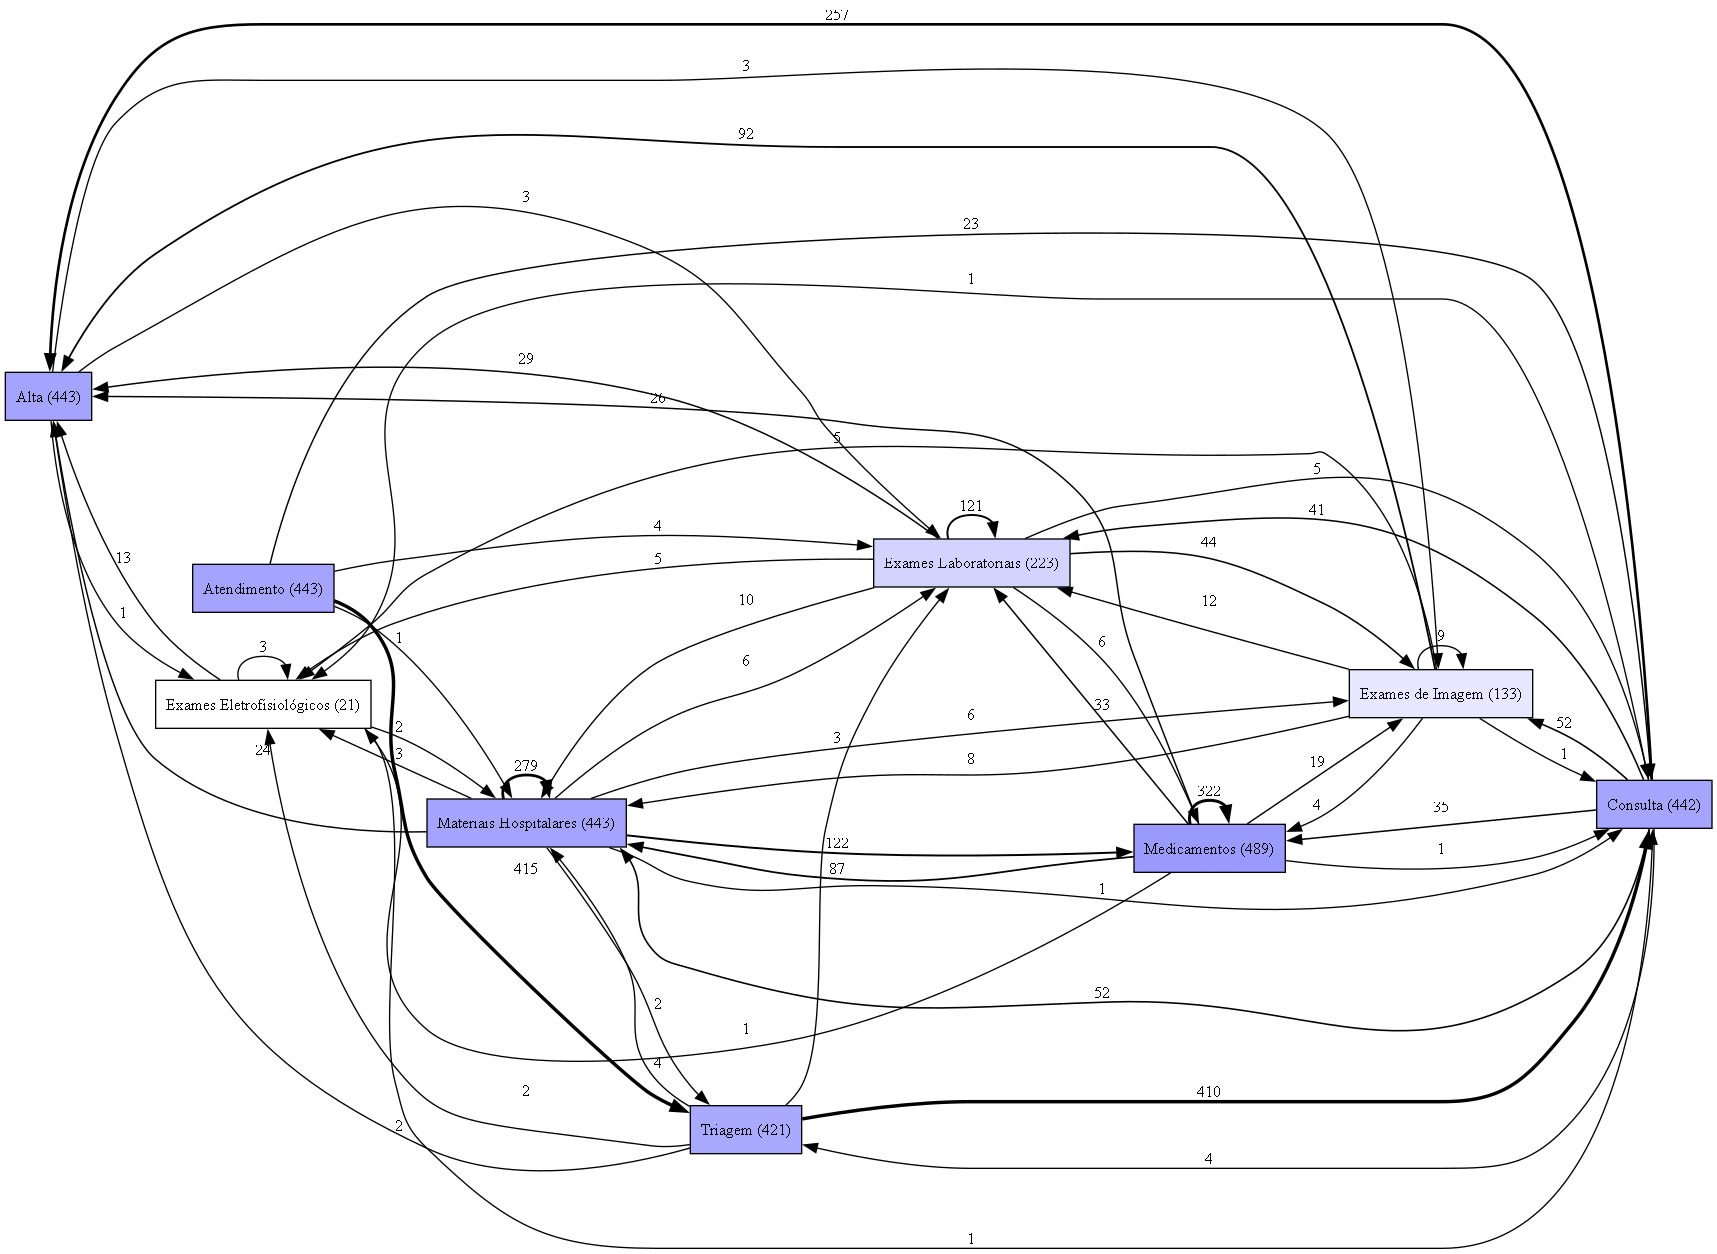

In [ ]:
from pm4py.visualization.dfg import visualizer as dfg_visualizer

# Generate and display the DFG visualization (frequency variant)
gviz_dfg = dfg_visualizer.apply(dfg, log=event_log, variant=dfg_visualizer.Variants.FREQUENCY)
dfg_visualizer.view(gviz_dfg)

#### Heuristic Net Visualization

This section visualizes the Heuristic Net, a model particularly effective for representing process flows in noisy real-world logs by emphasizing the most frequent paths and mitigating the impact of less common behavior.

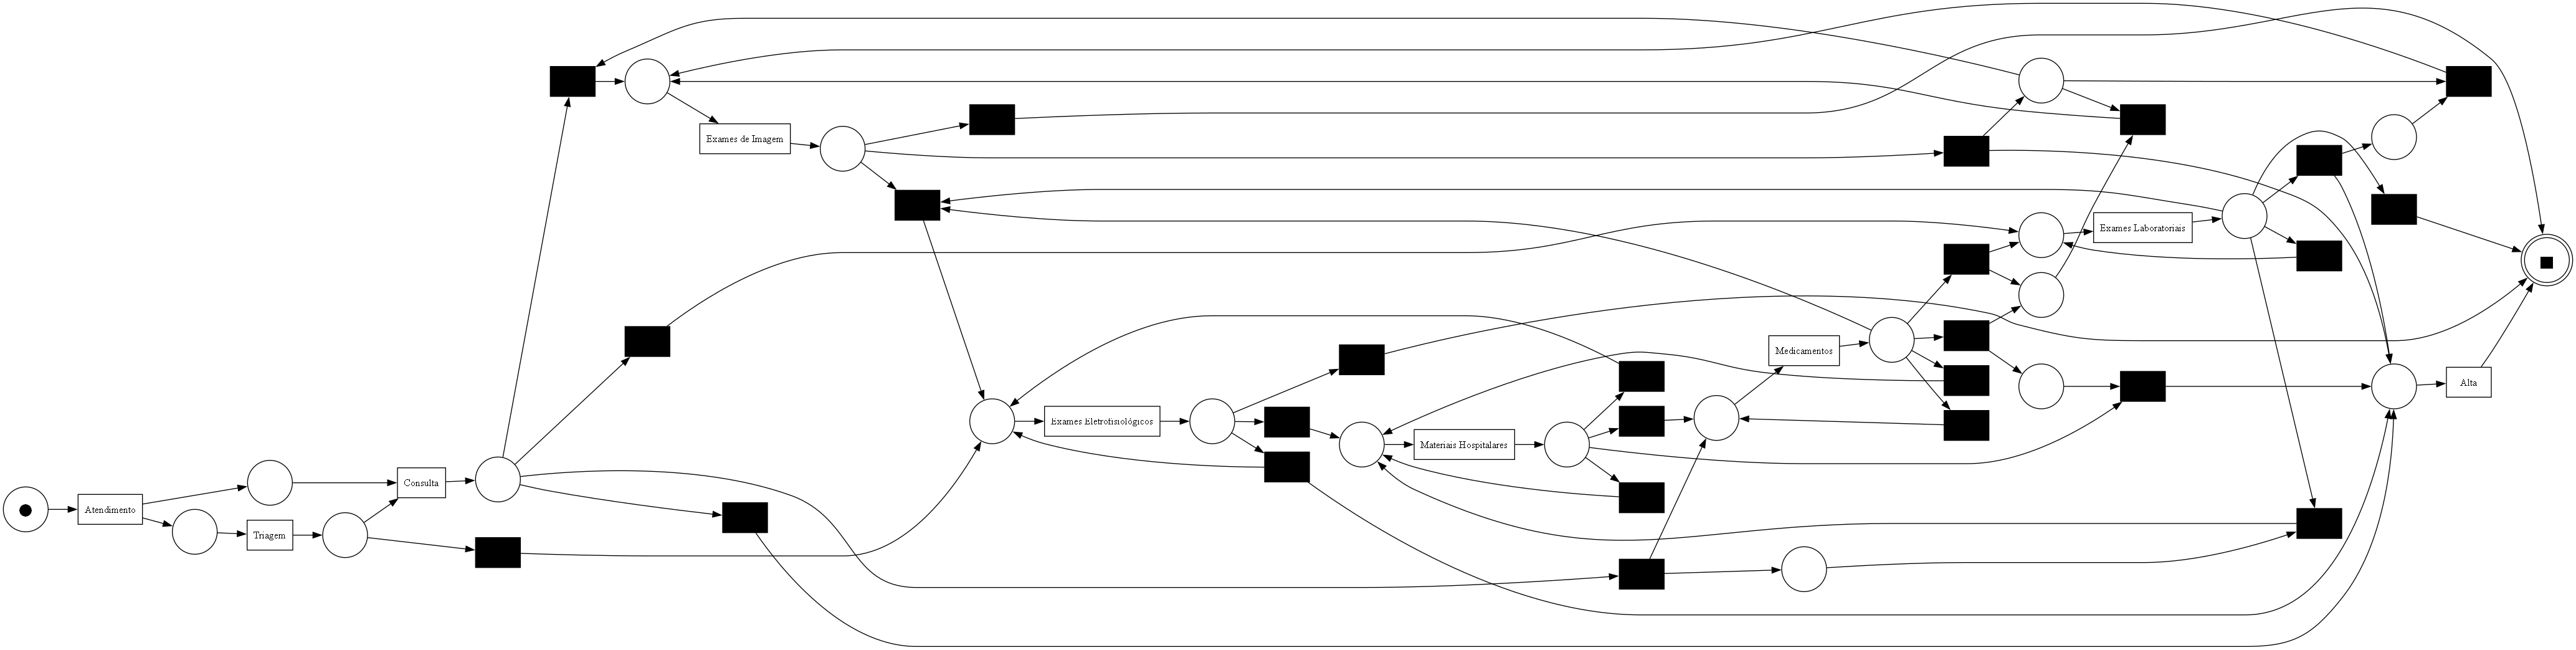

In [ ]:
from pm4py.visualization.petri_net import visualizer as pn_visualizer

# Generate and display the Petri Net visualization from Heuristic Miner's output
gviz_hn = pn_visualizer.apply(net_heur, im_heur, fm_heur, parameters={"format": "png"})
pn_visualizer.view(gviz_hn)

#### Inductive Miner (Petri Net) Visualization

This section presents the Petri Net discovered by the Inductive Miner, which generates a sound and structured process model ensuring properties such as absence of deadlocks and proper termination.

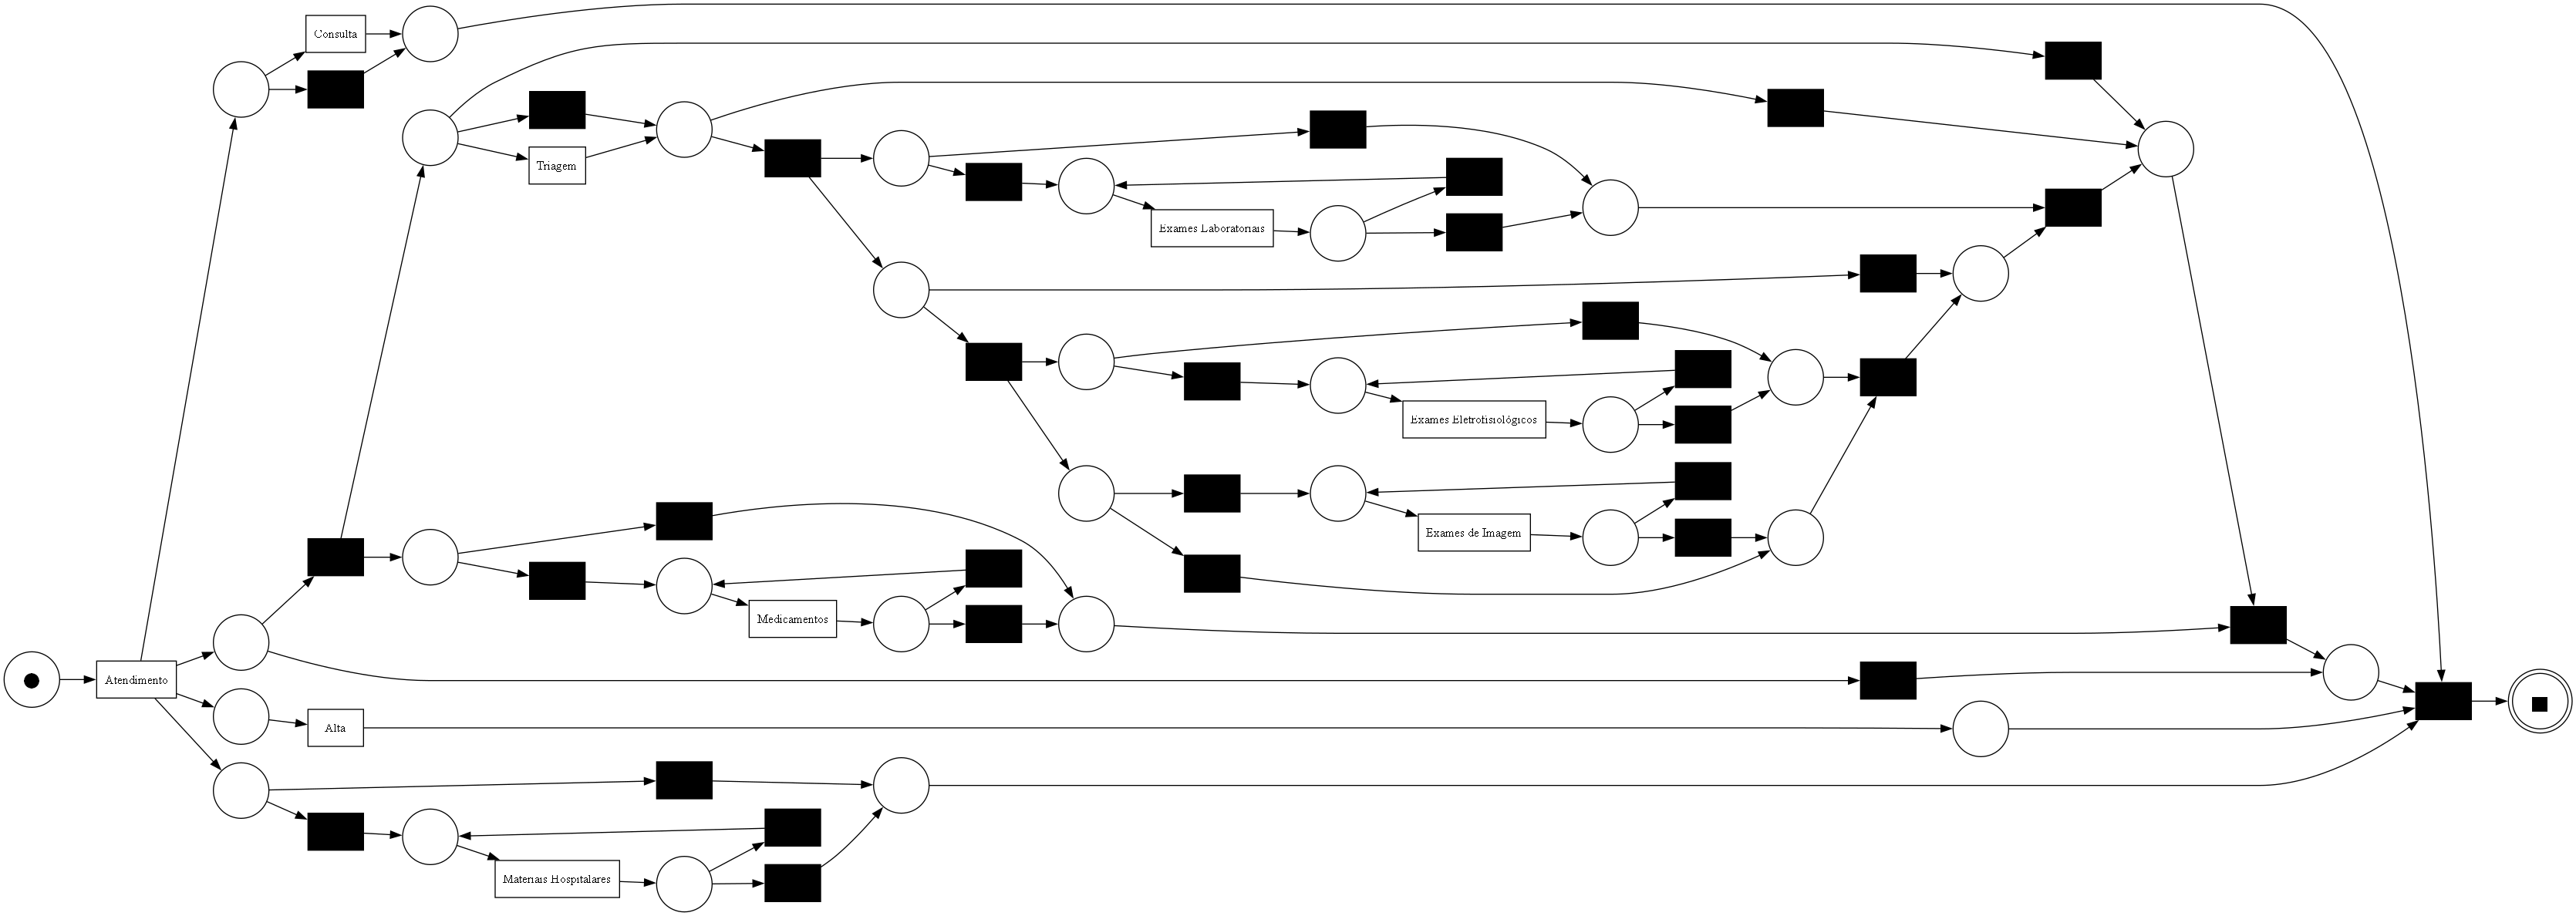

In [ ]:
from pm4py.visualization.petri_net import visualizer as pn_visualizer

# Generate and display the Petri Net visualization from Inductive Miner
gviz_ind = pn_visualizer.apply(net_ind, im_ind, fm_ind, parameters={pn_visualizer.Variants.FREQUENCY.value.Parameters.FORMAT: "png"})
pn_visualizer.view(gviz_ind)

#### 7. Insights

Based on the analysis from the preceding steps, the following insights and observations are derived through a thorough examination of process metrics, discovered models, and outlier analysis.

*   **Case Duration by Urgency**: High urgency cases exhibit significantly longer durations, indicating increased process complexity and resource consumption compared to less urgent cases.
*   **Rework by Disease**: Certain disease categories are associated with a higher incidence of rework, suggesting potential areas for protocol optimization or enhanced clinical pathways.
*   **Outlier Process Characteristics**: Outlier cases frequently display highly fragmented or circular paths compared to normal cases. This structural difference, coupled with longer durations, larger case sizes, and significantly higher rework, indicates deviations from standard protocol rather than merely extended waiting times.
*   **Bottleneck Identification**: Activities such as 'Triage' or 'Waiting for Doctor' appear to function as bottlenecks within the overall process. Their high frequency in the DFG, combined with their contribution to extended case durations, highlights them as critical points for process improvement.
*   **Activity Frequency in Outliers**: Specific activities demonstrate a disproportionately higher relative frequency in outlier cases. This suggests these activities are critical points contributing to rework or extended processing times in deviant process instances.

#### 8. Improvement

**Objective**: To propose evidence-based improvements aimed at enhancing process efficiency and patient care within the emergency department.

Based on the derived insights, the following recommendations are proposed to optimize the patient treatment process:

*   **Reduction of Rework**: Outlier cases are characterized by significantly higher rework. Implementing standardized protocols or checklists for activities frequently involved in rework (particularly those identified through activity frequency comparison) can ensure completeness on the first attempt and reduce repetitions.
*   **Case Complexity Differentiation**: The considerably larger case size observed in outlier instances suggests the need for early identification and differentiation of complex cases. Assigning appropriate resources and specialized pathways at an earlier stage can prevent these cases from developing into long-duration, high-rework instances.
*   **Fast-Track for Normal Cases**: Given that the majority of normal cases are characterized by compact execution, fewer events, and low rework, establishing a 'fast-track' process for these standard cases could optimize resource allocation and improve patient flow.
*   **Automation and Documentation for Frequent Activities**: Activities such as 'Medicamentos' (Medication), 'Materiais Hospitalares' (Hospital Materials), 'Atendimento' (Attendance), 'Alta' (Discharge), 'Consulta' (Consultation), and 'Triagem' (Triage) exhibit high frequency across the log. Streamlining these processes through automation (e.g., AI-driven triage, automated prescription filling) or enhancing documentation can significantly improve efficiency across all case types.
*   **Resource Reallocation**: Analysis of activity frequency and rework patterns can inform strategic reallocation of staff or equipment. Prioritizing areas with high demand or recurring issues, especially departments handling activities prevalent in outlier cases, can lead to targeted improvements.

### Conclusion

This analysis demonstrates the utility of process mining in transforming raw healthcare data into actionable insights for improving efficiency and patient care. A key finding is that outlier cases are not only characterized by longer durations but also by structurally greater complexity, encompassing larger case sizes and significantly higher rework. This suggests that inefficiency within the emergency department is not solely attributable to waiting times but also to fragmented or repeated execution patterns. The identified areas for improvement, such as targeted rework reduction, early complexity differentiation, fast-tracking for standard cases, automation of frequent activities, and strategic resource reallocation, offer concrete pathways to enhance process performance and optimize patient outcomes.